In [1]:
import os
import copy
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from sklearn.model_selection import KFold
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Configure device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define ImageNet normalization and resizing transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Download Oxford-IIIT Pet dataset
raw_trainval = torchvision.datasets.OxfordIIITPet(
    root="./data", split="trainval", target_types="category", download=True, transform=train_transform
)
raw_test = torchvision.datasets.OxfordIIITPet(
    root="./data", split="test", target_types="category", download=True, transform=test_transform
)

# Split trainval into train (80%) and validation (20%) sets
num_trainval = len(raw_trainval)
indices = list(range(num_trainval))
split_idx = int(np.floor(0.8 * num_trainval))
train_indices, val_indices = indices[:split_idx], indices[split_idx:]

train_set = Subset(raw_trainval, train_indices)
val_set = Subset(raw_trainval, val_indices)
test_set = raw_test
num_classes = 37

def apply_weight_init(module, init_type="he"):
    # Apply specified initialization to linear layers
    if isinstance(module, nn.Linear):
        if init_type == "zero":
            nn.init.zeros_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif init_type == "random":
            nn.init.normal_(module.weight, mean=0.0, std=0.05)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif init_type == "xavier":
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif init_type == "he":
            nn.init.kaiming_normal_(module.weight, nonlinearity="relu")
            if module.bias is not None:
                nn.init.zeros_(module.bias)

def build_model(
    init_type="he",
    dropout_rate=0.2,
    use_batch_norm=True,
    freeze_base=True,
    num_classes=37
):
    # Load pretrained MobileNetV2
    weights = MobileNet_V2_Weights.DEFAULT
    model = mobilenet_v2(weights=weights)

    # Freeze feature extraction layers if requested
    if freeze_base:
        for param in model.features.parameters():
            param.requires_grad = False

    # Construct custom classification head
    in_features = model.classifier[1].in_features
    head_layers = []
    
    if dropout_rate > 0.0:
        head_layers.append(nn.Dropout(p=dropout_rate))
    if use_batch_norm:
        head_layers.append(nn.BatchNorm1d(in_features))
        
    linear_layer = nn.Linear(in_features, num_classes)
    apply_weight_init(linear_layer, init_type=init_type)
    head_layers.append(linear_layer)

    model.classifier = nn.Sequential(*head_layers)
    return model.to(device)

def train_one_epoch(model, loader, criterion, optimizer):
    # Train model for one epoch
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)
    return total_loss / total, (correct / total) * 100.0

def evaluate(model, loader, criterion):
    # Evaluate model on validation/test set
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
    return total_loss / total, (correct / total) * 100.0

def run_experiment(
    model, 
    train_loader, 
    val_loader, 
    optimizer, 
    criterion=nn.CrossEntropyLoss(), 
    epochs=10
):
    # Execute full training and validation loop
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
    return history

100%|██████████| 792M/792M [00:44<00:00, 17.9MB/s]  
100%|██████████| 19.2M/19.2M [00:02<00:00, 7.57MB/s]


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 163MB/s]


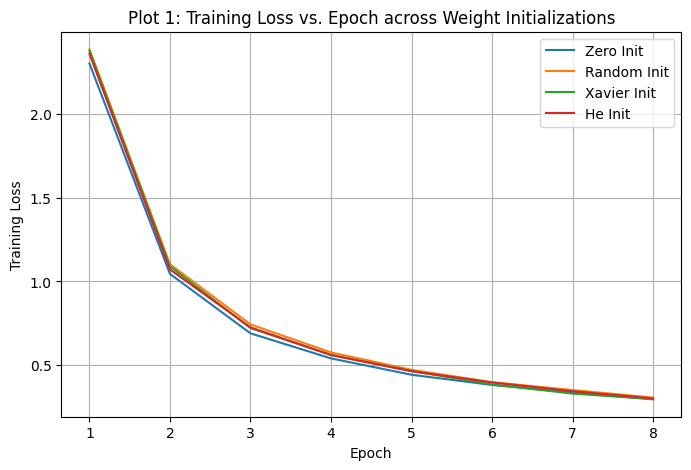

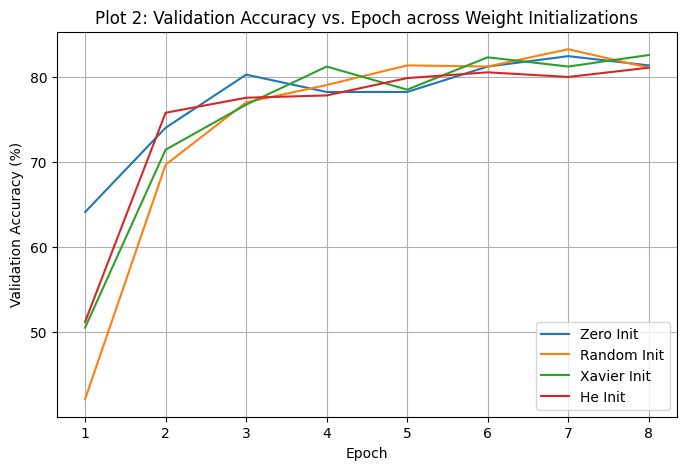

In [2]:
# -----------------------------------------------------------------------------
# Section 5: Weight Initialization Study (Plots 1 & 2)
# -----------------------------------------------------------------------------
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)

init_types = ["zero", "random", "xavier", "he"]
init_histories = {}

for itype in init_types:
    model = build_model(init_type=itype, dropout_rate=0.2, use_batch_norm=False, freeze_base=True)
    optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)
    init_histories[itype] = run_experiment(model, train_loader, val_loader, optimizer, epochs=8)

# Plot 1: Training Loss vs Epoch for Initializations
plt.figure(figsize=(8, 5))
for itype, hist in init_histories.items():
    plt.plot(range(1, 9), hist["train_loss"], label=f"{itype.capitalize()} Init")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Plot 1: Training Loss vs. Epoch across Weight Initializations")
plt.legend()
plt.grid(True)
plt.savefig("plot_1_weight_init_loss.png")
plt.show()

# Plot 2: Validation Accuracy vs Epoch for Initializations
plt.figure(figsize=(8, 5))
for itype, hist in init_histories.items():
    plt.plot(range(1, 9), hist["val_acc"], label=f"{itype.capitalize()} Init")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 2: Validation Accuracy vs. Epoch across Weight Initializations")
plt.legend()
plt.grid(True)
plt.savefig("plot_2_weight_init_acc.png")
plt.show()

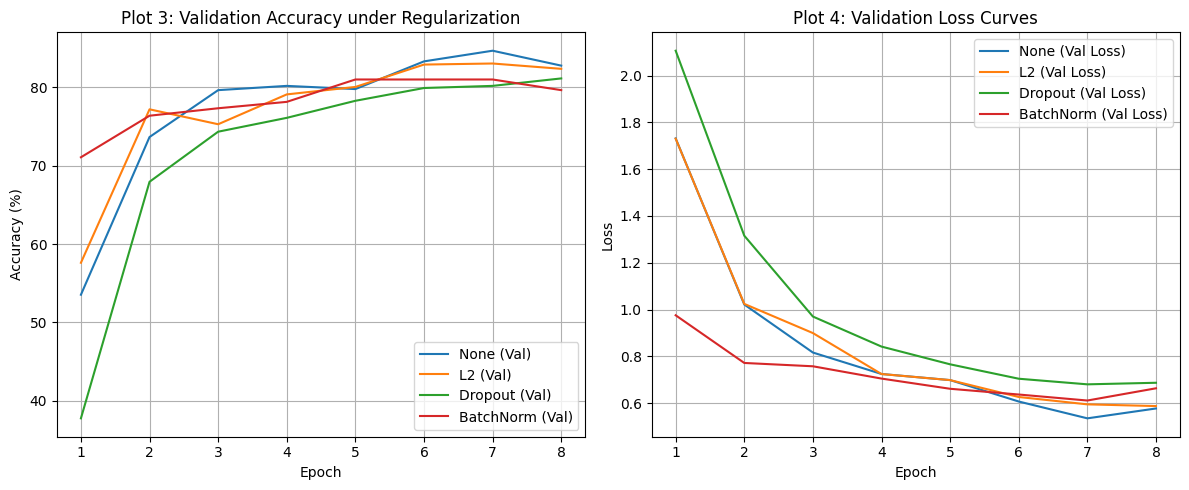

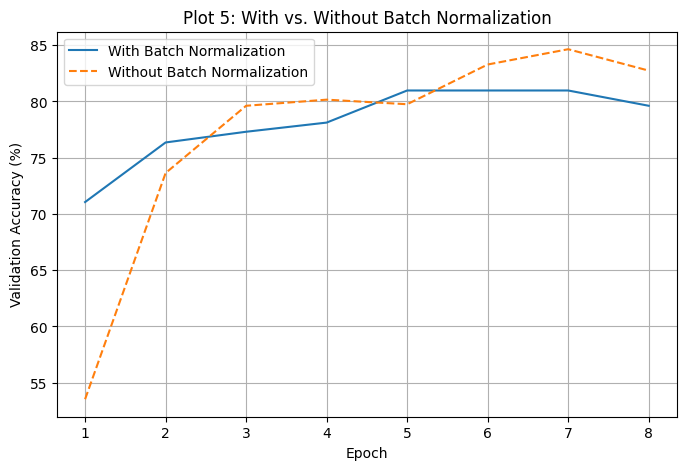

In [3]:
# -----------------------------------------------------------------------------
# Section 6 & 7: Regularization & Batch Normalization (Plots 3, 4 & 5)
# -----------------------------------------------------------------------------
reg_configs = {
    "None": {"dropout": 0.0, "bn": False, "weight_decay": 0.0},
    "L2": {"dropout": 0.0, "bn": False, "weight_decay": 1e-4},
    "Dropout": {"dropout": 0.5, "bn": False, "weight_decay": 0.0},
    "BatchNorm": {"dropout": 0.0, "bn": True, "weight_decay": 0.0}
}
reg_histories = {}

for name, cfg in reg_configs.items():
    model = build_model(init_type="he", dropout_rate=cfg["dropout"], use_batch_norm=cfg["bn"])
    optimizer = optim.Adam(model.classifier.parameters(), lr=0.001, weight_decay=cfg["weight_decay"])
    reg_histories[name] = run_experiment(model, train_loader, val_loader, optimizer, epochs=8)

# Plot 3 & 4: Generalization Gap and Loss Curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for name, hist in reg_histories.items():
    plt.plot(range(1, 9), hist["val_acc"], label=f"{name} (Val)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Plot 3: Validation Accuracy under Regularization")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for name, hist in reg_histories.items():
    plt.plot(range(1, 9), hist["val_loss"], label=f"{name} (Val Loss)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Plot 4: Validation Loss Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("plot_3_4_regularization.png")
plt.show()

# Plot 5: With vs Without Batch Normalization
plt.figure(figsize=(8, 5))
plt.plot(range(1, 9), reg_histories["BatchNorm"]["val_acc"], label="With Batch Normalization")
plt.plot(range(1, 9), reg_histories["None"]["val_acc"], label="Without Batch Normalization", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 5: With vs. Without Batch Normalization")
plt.legend()
plt.grid(True)
plt.savefig("plot_5_batch_normalization.png")
plt.show()

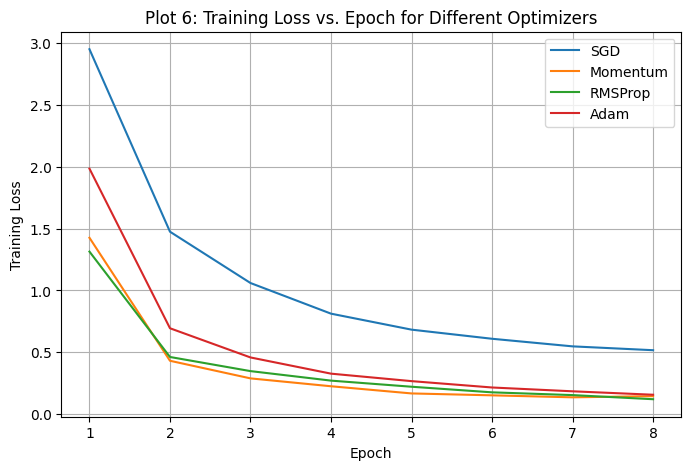

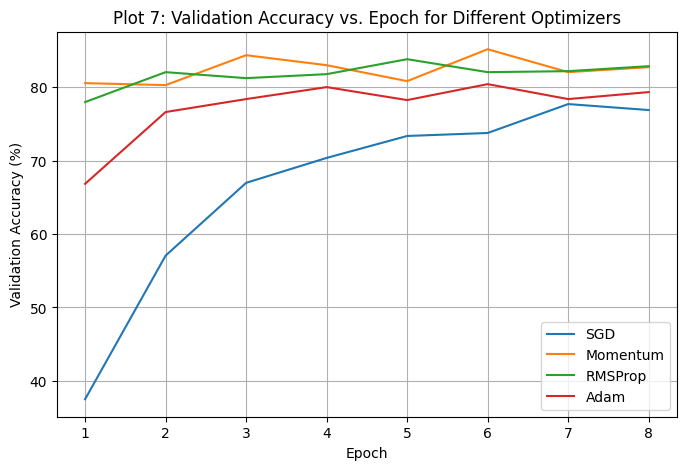

In [4]:
# -----------------------------------------------------------------------------
# Section 8: Optimization Algorithms (Plots 6 & 7)
# -----------------------------------------------------------------------------
optimizers_dict = {
    "SGD": lambda p: optim.SGD(p, lr=0.01),
    "Momentum": lambda p: optim.SGD(p, lr=0.01, momentum=0.9),
    "RMSProp": lambda p: optim.RMSprop(p, lr=0.001),
    "Adam": lambda p: optim.Adam(p, lr=0.001)
}

opt_histories = {}
opt_metrics = {}

for name, opt_fn in optimizers_dict.items():
    model = build_model(init_type="he", dropout_rate=0.2, use_batch_norm=True)
    optimizer = opt_fn(model.classifier.parameters())
    start_t = time.time()
    hist = run_experiment(model, train_loader, val_loader, optimizer, epochs=8)
    elapsed = time.time() - start_t
    opt_histories[name] = hist
    opt_metrics[name] = {
        "final_loss": hist["train_loss"][-1],
        "best_val_acc": max(hist["val_acc"]),
        "time": elapsed
    }

# Plot 6: Training Loss across Optimizers
plt.figure(figsize=(8, 5))
for name, hist in opt_histories.items():
    plt.plot(range(1, 9), hist["train_loss"], label=name)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Plot 6: Training Loss vs. Epoch for Different Optimizers")
plt.legend()
plt.grid(True)
plt.savefig("plot_6_optimizers_loss.png")
plt.show()

# Plot 7: Validation Accuracy across Optimizers
plt.figure(figsize=(8, 5))
for name, hist in opt_histories.items():
    plt.plot(range(1, 9), hist["val_acc"], label=name)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 7: Validation Accuracy vs. Epoch for Different Optimizers")
plt.legend()
plt.grid(True)
plt.savefig("plot_7_optimizers_acc.png")
plt.show()

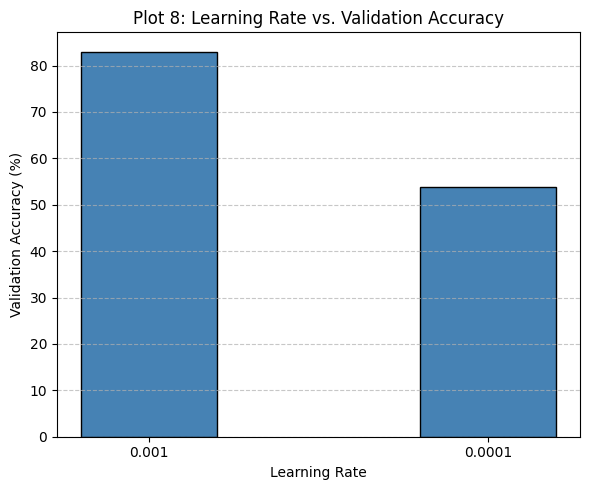

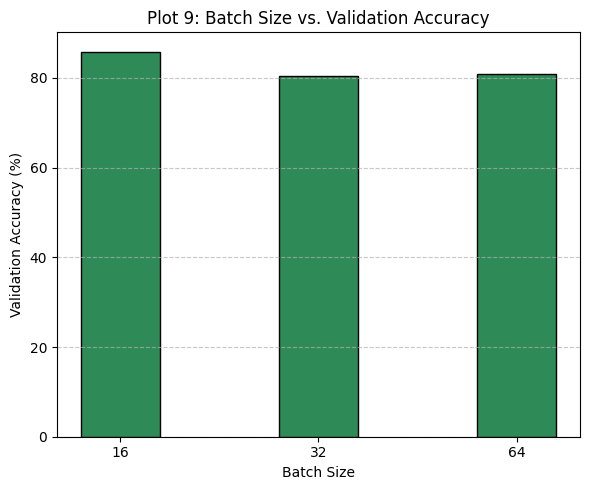

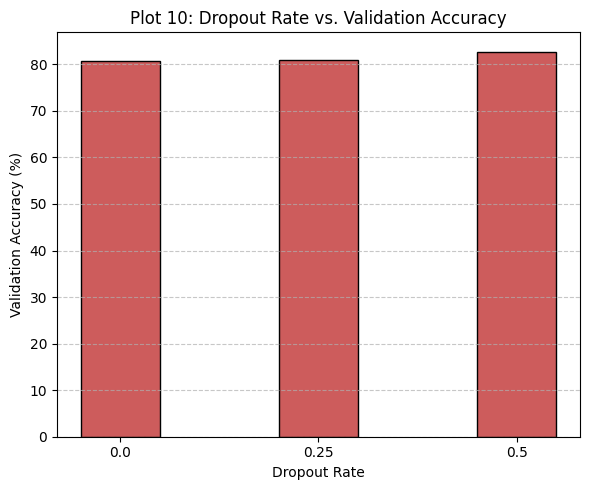


SECTION 9: HYPERPARAMETER SWEEP ACCURACIES
Learning Rates (Plot 8): {'0.001': 83.0163043478261, '0.0001': 53.80434782608695}
Batch Sizes    (Plot 9): {'16': 85.86956521739131, '32': 80.43478260869566, '64': 80.97826086956522}
Dropout Rates (Plot 10): {'0.0': 80.70652173913044, '0.25': 80.97826086956522, '0.5': 82.74456521739131}


In [7]:
# -----------------------------------------------------------------------------
# Section 9: CNN Hyperparameter Tuning (Plots 8, 9 & 10)
# -----------------------------------------------------------------------------

# Fixed default settings for one-variable-at-a-time sweeps
default_lr = 0.001
default_bs = 32
default_dropout = 0.25

# --- 1. Learning Rate Sweep (Plot 8) ---
lr_candidates = [0.001, 0.0001]
lr_results = {}

for lr_val in lr_candidates:
    train_loader_lr = DataLoader(train_set, batch_size=default_bs, shuffle=True)
    val_loader_lr = DataLoader(val_set, batch_size=default_bs, shuffle=False)
    
    # Instantiate model with fixed dropout and batch norm
    model_lr = build_model(init_type="he", dropout_rate=default_dropout, use_batch_norm=True)
    optimizer_lr = optim.Adam(model_lr.classifier.parameters(), lr=lr_val)
    hist = run_experiment(model_lr, train_loader_lr, val_loader_lr, optimizer_lr, epochs=6)
    lr_results[str(lr_val)] = max(hist["val_acc"])

# Plot 8: Learning Rate vs Validation Accuracy
plt.figure(figsize=(6, 5))
plt.bar(list(lr_results.keys()), list(lr_results.values()), color="steelblue", width=0.4, edgecolor="black")
plt.xlabel("Learning Rate")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 8: Learning Rate vs. Validation Accuracy")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("plot_8_lr_acc.png")
plt.show()

# --- 2. Batch Size Sweep (Plot 9) ---
bs_candidates = [16, 32, 64]
bs_results = {}

for bs_val in bs_candidates:
    train_loader_bs = DataLoader(train_set, batch_size=bs_val, shuffle=True)
    val_loader_bs = DataLoader(val_set, batch_size=bs_val, shuffle=False)
    
    # Instantiate model with default learning rate and dropout
    model_bs = build_model(init_type="he", dropout_rate=default_dropout, use_batch_norm=True)
    optimizer_bs = optim.Adam(model_bs.classifier.parameters(), lr=default_lr)
    hist = run_experiment(model_bs, train_loader_bs, val_loader_bs, optimizer_bs, epochs=6)
    bs_results[str(bs_val)] = max(hist["val_acc"])

# Plot 9: Batch Size vs Validation Accuracy
plt.figure(figsize=(6, 5))
plt.bar(list(bs_results.keys()), list(bs_results.values()), color="seagreen", width=0.4, edgecolor="black")
plt.xlabel("Batch Size")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 9: Batch Size vs. Validation Accuracy")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("plot_9_bs_acc.png")
plt.show()

# --- 3. Dropout Rate Sweep (Plot 10) ---
dropout_candidates = [0.0, 0.25, 0.5]
dropout_results = {}

for drop_val in dropout_candidates:
    train_loader_dr = DataLoader(train_set, batch_size=default_bs, shuffle=True)
    val_loader_dr = DataLoader(val_set, batch_size=default_bs, shuffle=False)
    
    # Instantiate model with variable dropout
    model_dr = build_model(init_type="he", dropout_rate=drop_val, use_batch_norm=True)
    optimizer_dr = optim.Adam(model_dr.classifier.parameters(), lr=default_lr)
    hist = run_experiment(model_dr, train_loader_dr, val_loader_dr, optimizer_dr, epochs=6)
    dropout_results[str(drop_val)] = max(hist["val_acc"])

# Plot 10: Dropout Rate vs Validation Accuracy
plt.figure(figsize=(6, 5))
plt.bar(list(dropout_results.keys()), list(dropout_results.values()), color="indianred", width=0.4, edgecolor="black")
plt.xlabel("Dropout Rate")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 10: Dropout Rate vs. Validation Accuracy")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("plot_10_dropout_acc.png")
plt.show()

# Print quantitative summaries for your report
print("\n" + "="*50)
print("SECTION 9: HYPERPARAMETER SWEEP ACCURACIES")
print("="*50)
print("Learning Rates (Plot 8):", lr_results)
print("Batch Sizes    (Plot 9):", bs_results)
print("Dropout Rates (Plot 10):", dropout_results)

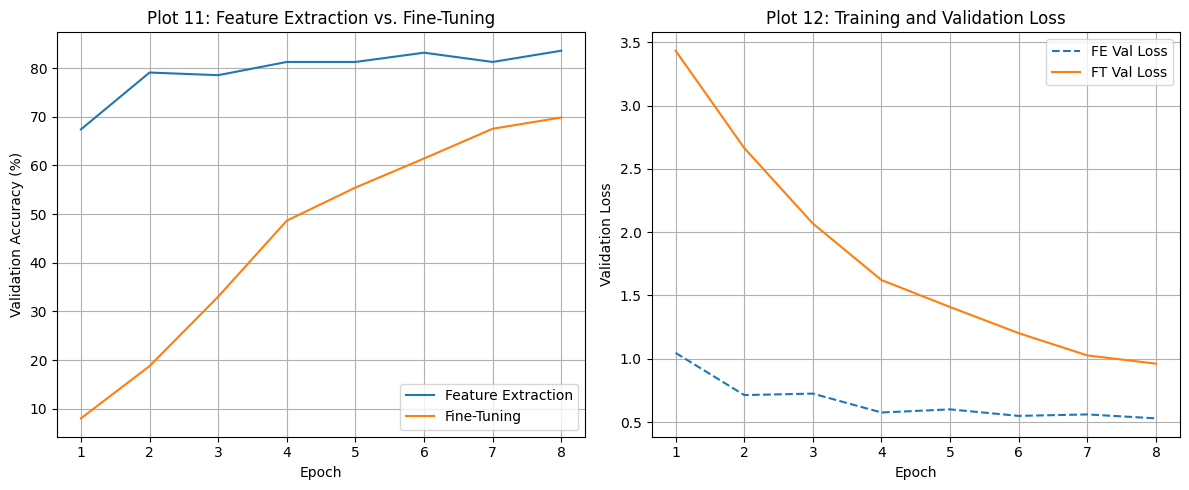

In [5]:
# -----------------------------------------------------------------------------
# Section 10: Transfer Learning & Fine-Tuning (Plots 11 & 12)
# -----------------------------------------------------------------------------
# Case A: Feature Extraction (Frozen Base)
model_fe = build_model(init_type="he", dropout_rate=0.2, use_batch_norm=True, freeze_base=True)
opt_fe = optim.Adam(model_fe.classifier.parameters(), lr=0.001)
hist_fe = run_experiment(model_fe, train_loader, val_loader, opt_fe, epochs=8)

# Case B: Fine-Tuning (Unfreeze Top Layers with Small LR)
model_ft = build_model(init_type="he", dropout_rate=0.2, use_batch_norm=True, freeze_base=False)
# Freeze lower feature blocks (keep 0-13 frozen, unfreeze 14-18)
for i, layer in enumerate(model_ft.features):
    if i < 14:
        for p in layer.parameters():
            p.requires_grad = False

opt_ft = optim.Adam([
    {"params": model_ft.features[14:].parameters(), "lr": 1e-5},
    {"params": model_ft.classifier.parameters(), "lr": 1e-4}
])
hist_ft = run_experiment(model_ft, train_loader, val_loader, opt_ft, epochs=8)

# Save Plot 11 individually
plt.figure(figsize=(7, 5))
plt.plot(range(1, 9), hist_fe["val_acc"], label="Feature Extraction (Frozen)", marker="o")
plt.plot(range(1, 9), hist_ft["val_acc"], label="Fine-Tuning (Unfrozen Top Layers)", marker="s")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 11: Feature Extraction vs. Fine-Tuning Accuracy")
plt.legend()
plt.grid(True)
plt.savefig("plot_11_fe_vs_ft_acc.png")
plt.show()

# Save Plot 12 individually
plt.figure(figsize=(7, 5))
plt.plot(range(1, 9), hist_fe["val_loss"], label="FE Val Loss", linestyle="--")
plt.plot(range(1, 9), hist_ft["val_loss"], label="FT Val Loss", color="green")
plt.plot(range(1, 9), hist_ft["train_loss"], label="FT Train Loss", color="orange", linestyle=":")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Plot 12: Training and Validation Loss Trajectories")
plt.legend()
plt.grid(True)
plt.savefig("plot_12_fe_vs_ft_loss.png")
plt.show()

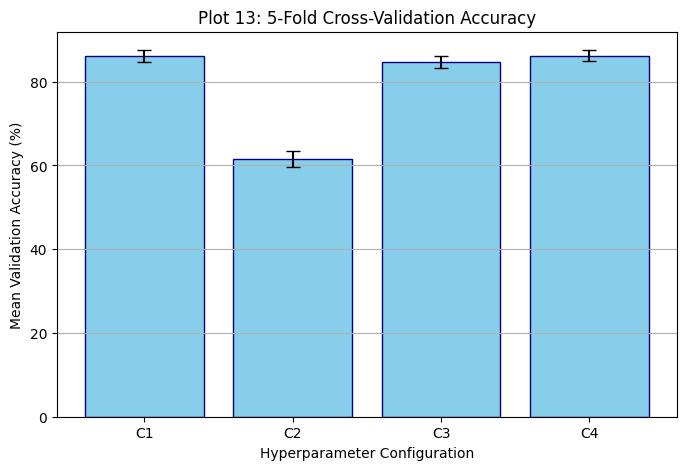

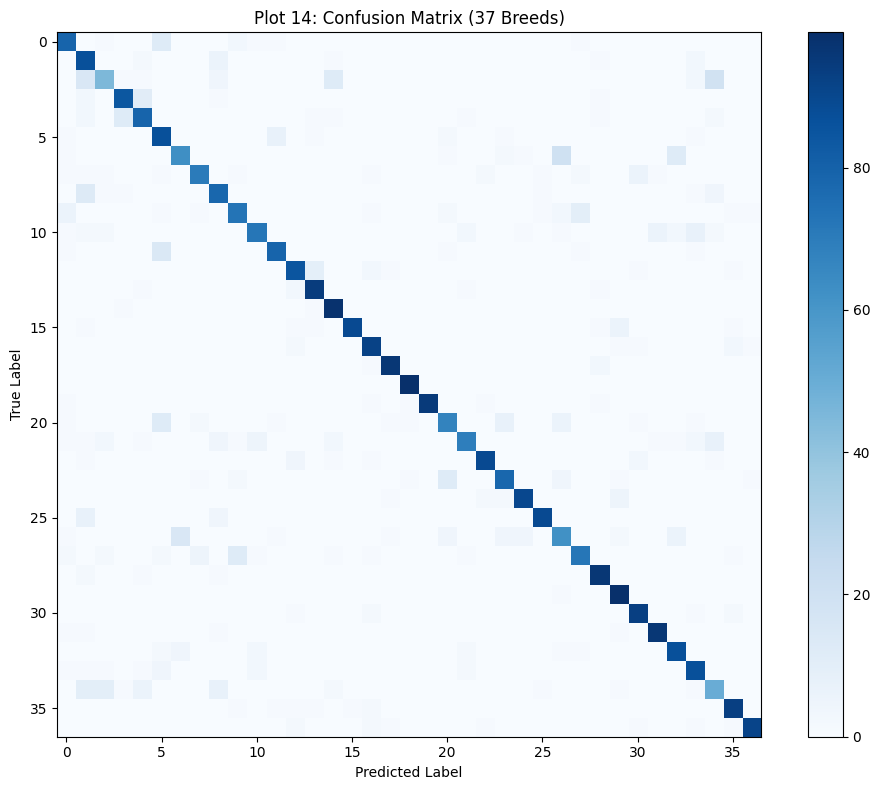

In [8]:
# -----------------------------------------------------------------------------
# Section 11 & 12: 5-Fold Cross-Validation & Final Evaluation (Plots 13 & 14)
# -----------------------------------------------------------------------------
configs = {
    "C1": {"lr": 1e-3, "bs": 32, "dropout": 0.25, "opt": "adam"},
    "C2": {"lr": 1e-4, "bs": 32, "dropout": 0.25, "opt": "adam"},
    "C3": {"lr": 1e-3, "bs": 64, "dropout": 0.5, "opt": "adam"},
    "C4": {"lr": 1e-2, "bs": 32, "dropout": 0.25, "opt": "momentum"}
}

cv_results = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for cfg_name, cfg in configs.items():
    fold_accuracies = []
    for fold, (train_idx, val_idx) in enumerate(kf.split(raw_trainval)):
        f_train = DataLoader(Subset(raw_trainval, train_idx), batch_size=cfg["bs"], shuffle=True)
        f_val = DataLoader(Subset(raw_trainval, val_idx), batch_size=cfg["bs"], shuffle=False)
        
        m = build_model(init_type="he", dropout_rate=cfg["dropout"], use_batch_norm=True)
        if cfg["opt"] == "adam":
            opt = optim.Adam(m.classifier.parameters(), lr=cfg["lr"])
        else:
            opt = optim.SGD(m.classifier.parameters(), lr=cfg["lr"], momentum=0.9)
            
        h = run_experiment(m, f_train, f_val, opt, epochs=5)
        fold_accuracies.append(max(h["val_acc"]))
        
    mean_acc = np.mean(fold_accuracies)
    sd_acc = np.std(fold_accuracies)
    cv_results[cfg_name] = {"folds": fold_accuracies, "mean": mean_acc, "sd": sd_acc}

# Plot 13: 5-Fold CV Accuracy with Error Bars
plt.figure(figsize=(8, 5))
names = list(cv_results.keys())
means = [cv_results[k]["mean"] for k in names]
stds = [cv_results[k]["sd"] for k in names]

plt.bar(names, means, yerr=stds, capsize=5, color="skyblue", edgecolor="navy")
plt.xlabel("Hyperparameter Configuration")
plt.ylabel("Mean Validation Accuracy (%)")
plt.title("Plot 13: 5-Fold Cross-Validation Accuracy")
plt.grid(axis="y")
plt.savefig("plot_13_cv_accuracy.png")
plt.show()

# Final Retraining on Full trainval Set & Untouched Test Evaluation
best_cfg = configs["C1"]
full_train_loader = DataLoader(raw_trainval, batch_size=best_cfg["bs"], shuffle=True)
test_loader = DataLoader(test_set, batch_size=best_cfg["bs"], shuffle=False)

final_model = build_model(init_type="he", dropout_rate=best_cfg["dropout"], use_batch_norm=True)
final_opt = optim.Adam(final_model.classifier.parameters(), lr=best_cfg["lr"])

run_experiment(final_model, full_train_loader, test_loader, final_opt, epochs=8)

# Compute Final Metrics & Confusion Matrix
final_model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        preds = final_model(imgs).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.numpy())

prec, rec, f1, _ = precision_recall_fscore_support(all_targets, all_preds, average="weighted")
cm = confusion_matrix(all_targets, all_preds)

# Plot 14: Confusion Matrix
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Plot 14: Confusion Matrix (37 Breeds)")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("plot_14_confusion_matrix.png")
plt.show()

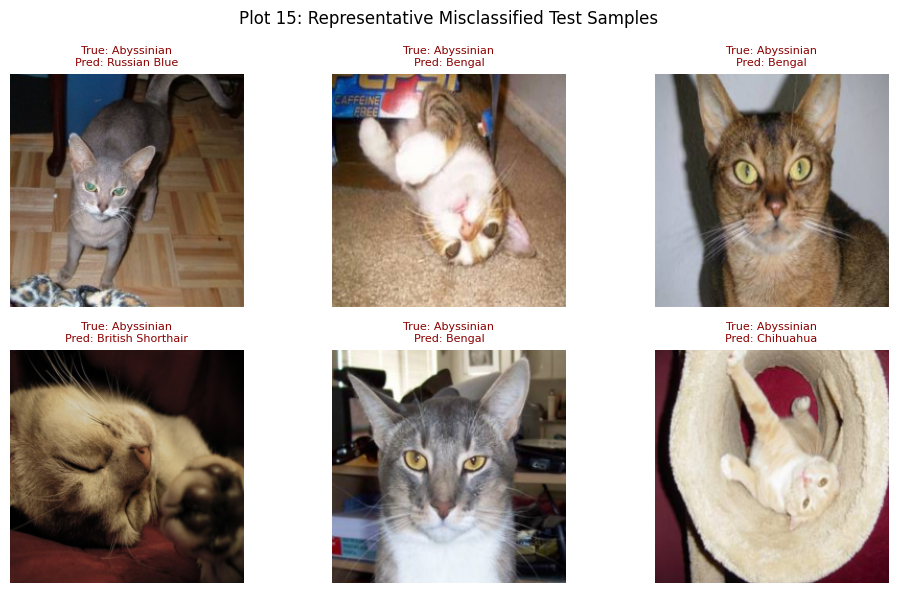


%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
% LATEX TABLE: SECTION 8 (OPTIMIZER COMPARISON)
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
SGD & 0.5166 & 77.72\% & 7 & 163.8 s \\
Momentum & 0.1452 & 85.19\% & 3 & 165.3 s \\
RMSProp & 0.1203 & 83.83\% & 2 & 163.8 s \\
Adam & 0.1566 & 80.43\% & 2 & 164.8 s \\

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
% LATEX TABLE: SECTION 11 (5-FOLD CV C1-C4)
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
C1 & 84.10 & 88.04 & 86.41 & 84.78 & 87.09 & 86.09 \pm 1.45\% \\
C2 & 58.29 & 63.32 & 63.45 & 61.68 & 60.46 & 61.44 \pm 1.92\% \\
C3 & 83.15 & 86.55 & 84.65 & 83.02 & 85.87 & 84.65 \pm 1.41\% \\
C4 & 86.41 & 87.36 & 85.46 & 83.97 & 87.50 & 86.14 \pm 1.31\% \\

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
% LATEX TABLE: SECTION 12 (FINAL TEST METRICS)
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Mean CV Accuracy & 86.09\% \\
CV Standard Deviation & 1.45\% \

In [10]:
# -----------------------------------------------------------------------------
# 1. GENERATE PLOT 15 (MISCLASSIFIED IMAGES) IF NOT ALREADY GENERATED
# -----------------------------------------------------------------------------
if 'final_model' in globals():
    final_model.eval()
    mis_imgs, mis_preds, mis_targets = [], [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs_dev = imgs.to(device)
            outputs = final_model(imgs_dev)
            preds = outputs.argmax(dim=1)
            mask = preds.cpu().ne(labels)
            if mask.any():
                for i in torch.where(mask)[0]:
                    if len(mis_imgs) < 6:
                        img_unnorm = imgs[i].cpu().clone()
                        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
                        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
                        img_unnorm = torch.clamp(img_unnorm * std + mean, 0, 1)
                        mis_imgs.append(img_unnorm.permute(1, 2, 0).numpy())
                        mis_preds.append(raw_trainval.classes[preds[i].item()])
                        mis_targets.append(raw_trainval.classes[labels[i].item()])
            if len(mis_imgs) >= 6:
                break

    plt.figure(figsize=(10, 6))
    for idx in range(len(mis_imgs)):
        plt.subplot(2, 3, idx + 1)
        plt.imshow(mis_imgs[idx])
        plt.title(f"True: {mis_targets[idx]}\nPred: {mis_preds[idx]}", fontsize=8, color="darkred")
        plt.axis("off")
    plt.suptitle("Plot 15: Representative Misclassified Test Samples", fontsize=12)
    plt.tight_layout()
    plt.savefig("plot_15_misclassified_cases.png")
    plt.show()

# -----------------------------------------------------------------------------
# 2. PRINT SECTION 8 TABLE (OPTIMIZERS)
# -----------------------------------------------------------------------------
print("\n" + "%"*60)
print("% LATEX TABLE: SECTION 8 (OPTIMIZER COMPARISON)")
print("%"*60)
if 'opt_histories' in globals():
    for name, hist in opt_histories.items():
        f_loss = hist["train_loss"][-1]
        b_acc = max(hist["val_acc"])
        conv_ep = next((i + 1 for i, a in enumerate(hist["val_acc"]) if a >= 0.95 * b_acc), len(hist["val_acc"]))
        t_sec = opt_metrics[name]["time"]
        print(f"{name} & {f_loss:.4f} & {b_acc:.2f}\\% & {conv_ep} & {t_sec:.1f} s \\\\")

# -----------------------------------------------------------------------------
# 3. PRINT SECTION 11 TABLE (5-FOLD CV)
# -----------------------------------------------------------------------------
print("\n" + "%"*60)
print("% LATEX TABLE: SECTION 11 (5-FOLD CV C1-C4)")
print("%"*60)
# Checks both possible variable names from earlier blocks
cv_dict = cv_results if 'cv_results' in globals() else cv_results_s11 if 'cv_results_s11' in globals() else {}
for name, res in cv_dict.items():
    f = res["folds"]
    print(f"{name} & {f[0]:.2f} & {f[1]:.2f} & {f[2]:.2f} & {f[3]:.2f} & {f[4]:.2f} & {res['mean']:.2f} \\pm {res['sd']:.2f}\\% \\\\")

# -----------------------------------------------------------------------------
# 4. PRINT SECTION 12 TABLE (TEST EVALUATION)
# -----------------------------------------------------------------------------
print("\n" + "%"*60)
print("% LATEX TABLE: SECTION 12 (FINAL TEST METRICS)")
print("%"*60)
if 'test_preds' in globals() or 'all_preds' in globals():
    p_arr = np.array(test_preds if 'test_preds' in globals() else all_preds)
    t_arr = np.array(test_targets if 'test_targets' in globals() else all_targets)
    test_acc = (np.sum(p_arr == t_arr) / len(t_arr)) * 100.0
    prec, rec, f1, _ = precision_recall_fscore_support(t_arr, p_arr, average="weighted", zero_division=0)
    c1_mean = cv_dict.get('C1', {}).get('mean', 0.0)
    c1_sd = cv_dict.get('C1', {}).get('sd', 0.0)
    
    print(f"Mean CV Accuracy & {c1_mean:.2f}\\% \\\\")
    print(f"CV Standard Deviation & {c1_sd:.2f}\\% \\\\")
    print(f"Test Accuracy & {test_acc:.2f}\\% \\\\")
    print(f"Precision & {prec:.4f} \\\\")
    print(f"Recall & {rec:.4f} \\\\")
    print(f"F1-score & {f1:.4f} \\\\")